## IMPORTING USEFUL LIBRARIES

In [ ]:
import sys

# Step 1: Install gpjax (brings in numpyro, jax, etc.)
!{sys.executable} -m pip install -q gpjax

# Step 2: Patch numpyro's provenance.py for JAX 0.10.0 compatibility
# (xla_pmap_p was removed in JAX 0.10.0 but numpyro 0.20.1 still references it)
!sed -i 's/from jax.extend.core.primitives import call_p, closed_call_p, jit_p, xla_pmap_p/from jax.extend.core.primitives import call_p, closed_call_p, jit_p/' \
    /usr/local/lib/python3.12/dist-packages/numpyro/ops/provenance.py

!sed -i 's/track_deps_rules\[xla_pmap_p\] = track_deps_call_rule//' \
    /usr/local/lib/python3.12/dist-packages/numpyro/ops/provenance.py

print("Patch applied. Now restart your session, then import gpjax.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.2/93.2 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.7/516.7 kB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 72.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 MB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 388.0/388.0 kB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.5/180.5 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.0 MB/s eta 0:00:00
Patch applied. Now restart your session, then import gpjax.


In [ ]:
import gpjax
print(gpjax.__version__)  # Should work cleanly

0.13.6


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import numpyro
import arviz as az

import jax
jax.config.update("jax_enable_x64", True)
import scipy
from scipy.interpolate import interp1d

from typing import Dict
import jax.numpy as jnp
from functools import partial
from jax import jit
from gpjax.mean_functions import AbstractMeanFunction
from gpjax.kernels import AbstractKernel
#import jax
import jax.numpy as jnp
#import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
from dataclasses import dataclass
from typing import Dict


## FORWARD MODEL

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.collections import PatchCollection
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import pandas as pd

# ── 1. USER INPUTS ────────────────────────────────────────────────────────────
z_erosion_base_FW = 250.0
z_erosion_base_HW = 400.0

layer_thickness   = 600.0   # uniform thickness for FW and HW (except near fault)

# ── 2. SPATIAL GRID ───────────────────────────────────────────────────────────
x_min, x_max = -4500.0, 4500.0
n_prisms = 50
x_edges   = np.linspace(x_min, x_max, n_prisms + 1)
x_centers = (x_edges[:-1] + x_edges[1:]) / 2

# ── 3. LAYER GEOMETRY (20° dip) — kept only for fault reference ───────────────
dip_layer_deg = 20.0
theta_layer   = np.radians(dip_layer_deg)

def get_z_init_top(x):
    return (x - 0) * (np.tan(theta_layer) / 10) + 200.0

# ── 4. FAULT GEOMETRY (40° dip) ───────────────────────────────────────────────
dip_fault_deg   = 40.0
theta_fault     = np.radians(dip_fault_deg)
fault_x_ref     = -1500.0
inv_slope_fault = 1.0 / np.tan(theta_fault)
fault_throw     = 100.0
fault_heave     = fault_throw * inv_slope_fault

def get_z_fault(x):
    return (x - fault_x_ref) * np.tan(theta_fault)

z_f_edges = get_z_fault(x_edges)



z_unc_edges = np.zeros(n_prisms+1)
for i in range(n_prisms):
    if x_edges[i] < fault_x_ref + ((z_erosion_base_FW * inv_slope_fault)):
       z_unc_edges[i]= z_erosion_base_FW + i*6
    else:
       z_unc_edges[i]= z_erosion_base_HW + i*6

# ── 7. TOP LAYER: bottom = erosion surface, top = surface ─────────────────────
# Bottom of top layer = erosion surface = top of FW/HW  (shared, zero gap)
z_top_layer_bottom = np.zeros(n_prisms)
for i in range(n_prisms):
    z_top_layer_bottom[i]=z_unc_edges[i].copy()
#z_top_layer_bottom = np.linspace(300,900,n_prisms+1)
z_top_layer_top    = np.zeros(n_prisms)   # 150 m thick top layer
for i in range(n_prisms):
    z_top_layer_top[i]=z_unc_edges[i].copy()-150
surface_layer_top = np.zeros(n_prisms) + 0.01
surface_layer_bottom = np.zeros(n_prisms)
for i in range(len(surface_layer_bottom)):
    surface_layer_bottom[i] = z_top_layer_top[i]

rho_surface = np.zeros(n_prisms)
for i in range(n_prisms):
    rho_surface[i]=-600 + (i*6)
rho_top=np.zeros(n_prisms)
for i in range(n_prisms):
    rho_top[i]=-450+i*4
# ── 9. BUILD POLYGON PATCHES ──────────────────────────────────────────────────
patches   = []
densities = []

def add_prisms(tops_edge, bases_edge, rho_array):
    row_idx = 0
    for i in range(n_prisms-1):
        if bases_edge[i] > tops_edge[i] + 0.1 or bases_edge[i+1] > tops_edge[i+1] + 0.1:
            xl, xr = x_edges[i], x_edges[i+1]
            tL, tR = tops_edge[i],  tops_edge[i+1]
            bL, bR = bases_edge[i], bases_edge[i+1]
            verts = np.array([[xl, tL], [xr, tR], [xr, bR], [xl, bL]])
            patches.append(mpatches.Polygon(verts, closed=True))
            densities.append(rho_array[row_idx])
            row_idx += 1

add_prisms(z_top_layer_top, z_top_layer_bottom, rho_top)
add_prisms(surface_layer_top, surface_layer_bottom, rho_surface)
# ── 10. PLOT ──────────────────────────────────────────────────────────────────
cmap    = plt.get_cmap('gist_rainbow', 100)
minimum = -350
maximum = -100
norm    = Normalize(vmin=minimum, vmax=maximum)

fig, ax = plt.subplots(figsize=(13, 7))

col = PatchCollection(patches, cmap=cmap, norm=norm,
                      edgecolors="#0c1117", linewidths=0.6)
col.set_array(densities)
ax.add_collection(col)

sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02, fraction=0.025)
cbar.set_label(r"Density Contrast $\rho$ (kg/m$^3$)", fontsize=11)

ax.set_xlim(x_min, x_max)
ax.set_ylim(1200, -60)
ax.set_xlabel("Horizontal Distance (m)", fontsize=11)
ax.set_ylabel("Depth (m)", fontsize=11)
ax.set_title("2D Geological Prism Model — Uniform Thickness FW/HW",
             fontsize=13, fontweight="normal", pad=12)


co = np.zeros(n_prisms)
for i in range(n_prisms):
    co[i]=x_centers[i]

wid = np.zeros(n_prisms)
for i in range(n_prisms):
    wid[i]=9000/n_prisms

## Anomaly calculation

In [ ]:
#Definng a new function g_anomaly to calculate gravity anomaly for a single prism
import numpy as np
def g_anomaly(x,A,m,D,d,rho):
    G=6.67*(10**-6)
    r1=(((x-A)+(0.5*m))**2)+((d)**2)
    r2=(((x-A)+(0.5*m))**2)+((D)**2)
    r3=(((x-A)-(0.5*m))**2)+((d)**2)
    r4=(((x-A)-(0.5*m))**2)+((D)**2)
    f1=np.arctan((x-A+(0.5*m))/(D))-np.arctan((x-A-(0.5*m))/(D))
    f2=np.arctan((x-A+(0.5*m))/d)-np.arctan((x-A-(0.5*m))/d)
    f3=0.5*(x-A)*(np.log10((r2*r3)/(r1*r4)))
    f4=0.25*m*(np.log10((r2*r4)/(r1*r3)))
    f=((D)*f1)-(d*f2)+f3+f4
    g=2*G*rho*f #in miligal
    return g

#Definng a new function g_n_anomaly to calculate summed gravity anomaly for n number of prisms
def g_n_anomaly(N,x,A,m,D,d,rho):
    u=0
    for i in range(N):
        v=g_anomaly(x,A[i],m[i],D[i],d[i],rho[i])
        u=u+v

    return u

In [ ]:
#Defining "measure_func" function to calculate gravity anomaly for combined two layers in miligal with user defined station coordinates and above defined model parameters with some added random noise
def measure_func(x):
    return  g_n_anomaly(n_prisms,x,co,wid,surface_layer_bottom,surface_layer_top,rho_surface)+g_n_anomaly(n_prisms,x,co,wid,z_top_layer_bottom,z_top_layer_top,rho_top)

In [ ]:
NUM_INIT_POINTS = 50 # number of observation points
X = np.linspace(-5000, 5000, NUM_INIT_POINTS)#Measurement points along the profile -5000 meter to 5000 meter
X_test = np.linspace(-5000, 5000, 200) #points taken for testing at finer intervals
ground_truth=measure_func(X_test) #gravity anomaly with no noise added

In [ ]:
n=n_prisms
bd1 = surface_layer_bottom
bd2 = z_top_layer_bottom
den1_L = rho_surface
den2_L = rho_top
#Creating x co-ordinate values for 1st layer for each prism
xs=np.zeros(n+1)
xs[0]=co[0]-(wid[0]*0.5)
xs[n]=co[n-1]+(wid[n-1]*0.5)
for i in range(1,n):
    xs[i]=co[i-1]+(0.5*wid[i-1])
#Creating z1 co-ordinate values for 1st layer for each prism
zs1=np.zeros(n+1)
zs1[0]=bd1[0]
zs1[n]=bd1[n-1]
for i in range(1,n):
    zs1[i]=bd1[i]
#Creating z2 co-ordinate values for 2nd layer for each prism
zs2=np.zeros(n+1)
zs2[0]=bd2[0]-5
zs2[n]=bd2[n-1]+5
for i in range(1,n):
    zs2[i]=(bd2[i-1]+bd2[i])*0.5
#Creating surface points
zs0=np.zeros(n+1)
R0=np.zeros(((n+1),2))
for i in range(n+1):
    R0[i]=[xs[i],zs0[i]]
#Creating points for 1st layer
R1=np.zeros(((n+1),2))
for i in range(n+1):
    R1[i]=[xs[i],zs1[i]]

#Creating points for 1st layer
R1_1=np.zeros(((n+1),2))
for i in range(n):
    R1_1[i]=[xs[i+1],zs1[i]]
#Creating points for 2nd layer
R2=np.zeros(((n+1),2))
for i in range(n+1):
    R2[i]=[xs[i],zs2[i]]
#Creating points for 1st layer
R2_1=np.zeros(((n+1),2))
for i in range(n):
    R2_1[i]=[xs[i+1],zs2[i]]

In [ ]:
from typing import Dict
import jax.numpy as jnp
from functools import partial
from jax import jit
from gpjax.mean_functions import AbstractMeanFunction
from gpjax.kernels import AbstractKernel
import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
from dataclasses import dataclass
from typing import Dict

jax.config.update("jax_enable_x64", True)




In [ ]:
#First defining the function g_ano() replacing jnp in place of np in the g_anomaly() function.
from os import name
def g_ano(x,A,m,D,d,rho):
    G=6.67*(10**-6)
    r1=(((x-A)+(0.5*m))**2)+((d)**2)
    r2=(((x-A)+(0.5*m))**2)+((D)**2)
    r3=(((x-A)-(0.5*m))**2)+((d)**2)
    r4=(((x-A)-(0.5*m))**2)+((D)**2)
    f1=jnp.arctan((x-A+(0.5*m))/D)-jnp.arctan((x-A-(0.5*m))/D)
    f2=jnp.arctan((x-A+(0.5*m))/d)-jnp.arctan((x-A-(0.5*m))/d)
    f3=0.5*(x-A)*(jnp.log10((r2*r3)/(r1*r4)))
    f4=0.25*m*(jnp.log10((r2*r4)/(r1*r3)))
    f=(D*f1)-(d*f2)+f3+f4
    return 2*G*rho*f


In [ ]:


# ═══════════════════════════════════════════════════════════════════════════════
# 1.  CUSTOM MATERN 3/2 KERNEL
# ═══════════════════════════════════════════════════════════════════════════════
def custom_Matern_kernel(
    X1: jnp.ndarray,
    X2: jnp.ndarray,
    params: Dict[str, jnp.ndarray],
    noise: jnp.ndarray = 0,
    **kwargs
) -> jnp.ndarray:
    """
    Matern 3/2 kernel with ARD support and numerical stability.

    FIX 1: X1_scaled / X2_scaled are now used consistently for the distance
    computation — the previous code divided X1/X2 at the top AND again inside
    the ARD branch, resulting in double-scaling and degenerate kernel values.
    """
    lengthscale = params["k_length"]
    variance    = params["k_scale"] ** 2      # square → standard convention
    jitter      = kwargs.get("jitter", 1e-6)

    # ── Single, correct scaling ───────────────────────────────────────────────
    if jnp.ndim(lengthscale) == 0 or jnp.shape(lengthscale)[0] == 1:
        # Isotropic
        X1_scaled = X1 / lengthscale
        X2_scaled = X2 / lengthscale
    else:
        # ARD — each feature has its own lengthscale
        X1_scaled = X1 / lengthscale
        X2_scaled = X2 / lengthscale

    # ── Pairwise squared distances on SCALED inputs ───────────────────────────
    D = (jnp.sum(X1_scaled ** 2, axis=1)[:, None]
         + jnp.sum(X2_scaled ** 2, axis=1)
         - 2.0 * jnp.dot(X1_scaled, X2_scaled.T))
    D = jnp.sqrt(jnp.maximum(D, 1e-12))       # clamp negatives from float err

    # ── Matern 3/2 formula ────────────────────────────────────────────────────
    sqrt3 = jnp.sqrt(3.0)
    K = variance * (1.0 + sqrt3 * D) * jnp.exp(-sqrt3 * D)

    # Add noise + jitter only on the diagonal (training covariance)
    if X1.shape == X2.shape:
        K += (noise + jitter) * jnp.eye(X1.shape[0])

    return K


# ── Kernel hyperparameter priors ──────────────────────────────────────────────
def custom_kernel_prior() -> Dict[str, jnp.ndarray]:
    """
    Priors for GP kernel hyperparameters.
    After X-normalisation the inputs live in roughly [-2, 2], so
    LogNormal(0, 1) for the lengthscale is now well-matched to the data scale.
    """
    k_scale  = numpyro.sample("k_scale",  dist.HalfNormal(1.0))
    k_length = numpyro.sample("k_length", dist.LogNormal(0.0, 1.0))
    return {"k_length": k_length, "k_scale": k_scale}


## LESS NOISE

In [ ]:
NUM_INIT_POINTS = 50 # number of observation points
X = np.linspace(-5000, 5000, NUM_INIT_POINTS)#Measurement points along the profile -5000 meter to 5000 meter
X_test = np.linspace(-5000, 5000, 200) #points taken for testing at finer intervals
ground_truth=measure_func(X_test) #gravity anomaly with no noise added
import tensorflow as tf
# Set seeds for reproducibility
SEED = 45
np.random.seed(SEED)
tf.random.set_seed(SEED)
#Generate Gaussian Noise
gaussian_noise = np.random.normal(0, 0.2, size=X.shape)
# Generate Random Walk Noise
# Step size is drawn from a normal distribution
random_steps = np.random.normal(0, 0.1, size=X.shape)
random_walk_noise = np.cumsum(random_steps)  # Cumulative sum to simulate random walk
#Salt & Pepper noise
salt_prob=0.05 #probability of salt(white) noise
pepper_prob=0.05 #probability of pepper(black) noise
noise_level=0.05 # 2% Salt & Pepper noise
salt_and_pepper_noise = (np.random.choice([0,1,-1],size=X.shape,p=[1 - (salt_prob + pepper_prob),salt_prob,pepper_prob]))*noise_level
#Systematic Noise (Assuming polynomial pattern of systematic noise with distance(x))
a,b,c=0.001,0.0001,0.001 #Co-efficients of Quadratic & Cubic terms
systematic_noise_level=0.05 # 1% Systematic noise
systematic_noise = systematic_noise_level*((a*((X*0.01)**2))+(b*((X*0.01)**3))+c)


#Adding noise to the gravity anomaly data

Y1 = measure_func(X) + 0.8*(random_walk_noise+ gaussian_noise+salt_and_pepper_noise+systematic_noise) #Gravity anomaly in miligal at station points with added noise (OBSERVED ANOMALY)


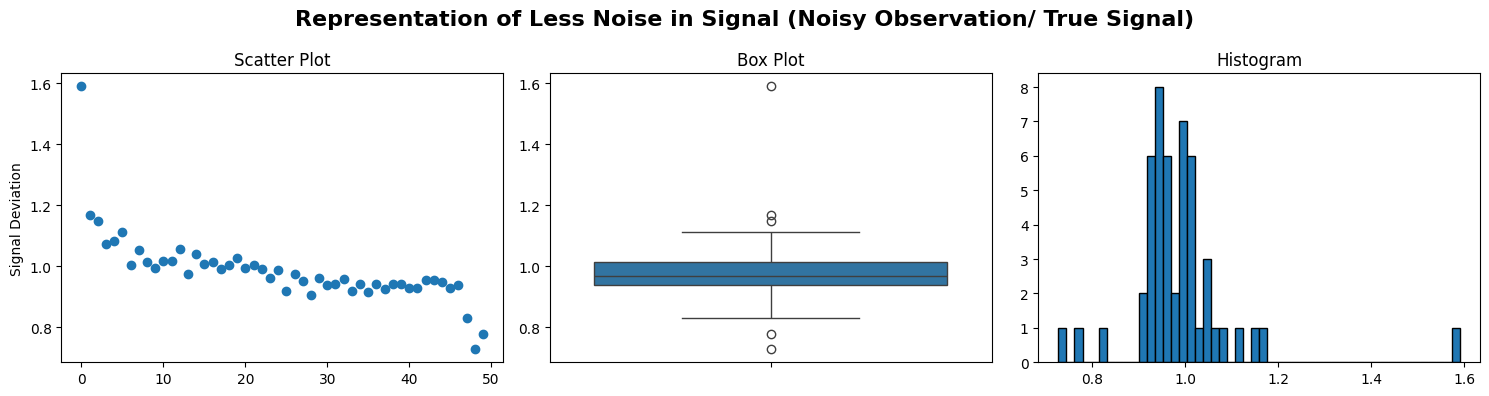

In [ ]:
import pandas as pd
import seaborn as sns

Signal_deviation=Y1/measure_func(X)
df = pd.DataFrame({'SNR': Signal_deviation})
fig, ax = plt.subplots(1,3, figsize=(15,4))

fig.suptitle("Representation of Less Noise in Signal (Noisy Observation/ True Signal)",fontsize=16,weight='bold')
# Scatter
ax[0].scatter(range(len(df)), df['SNR'])
ax[0].set_title("Scatter Plot")
ax[0].set_ylabel("Signal Deviation")

# Boxplot
sns.boxplot(y=df['SNR'], ax=ax[1])
ax[1].set_title("Box Plot")
ax[1].set_ylabel(None)

# Histogram
ax[2].hist(df['SNR'], bins=50, edgecolor='black')
#ax[2].set_xlim(0,2)
ax[2].set_title("Histogram")

plt.tight_layout()
plt.show()

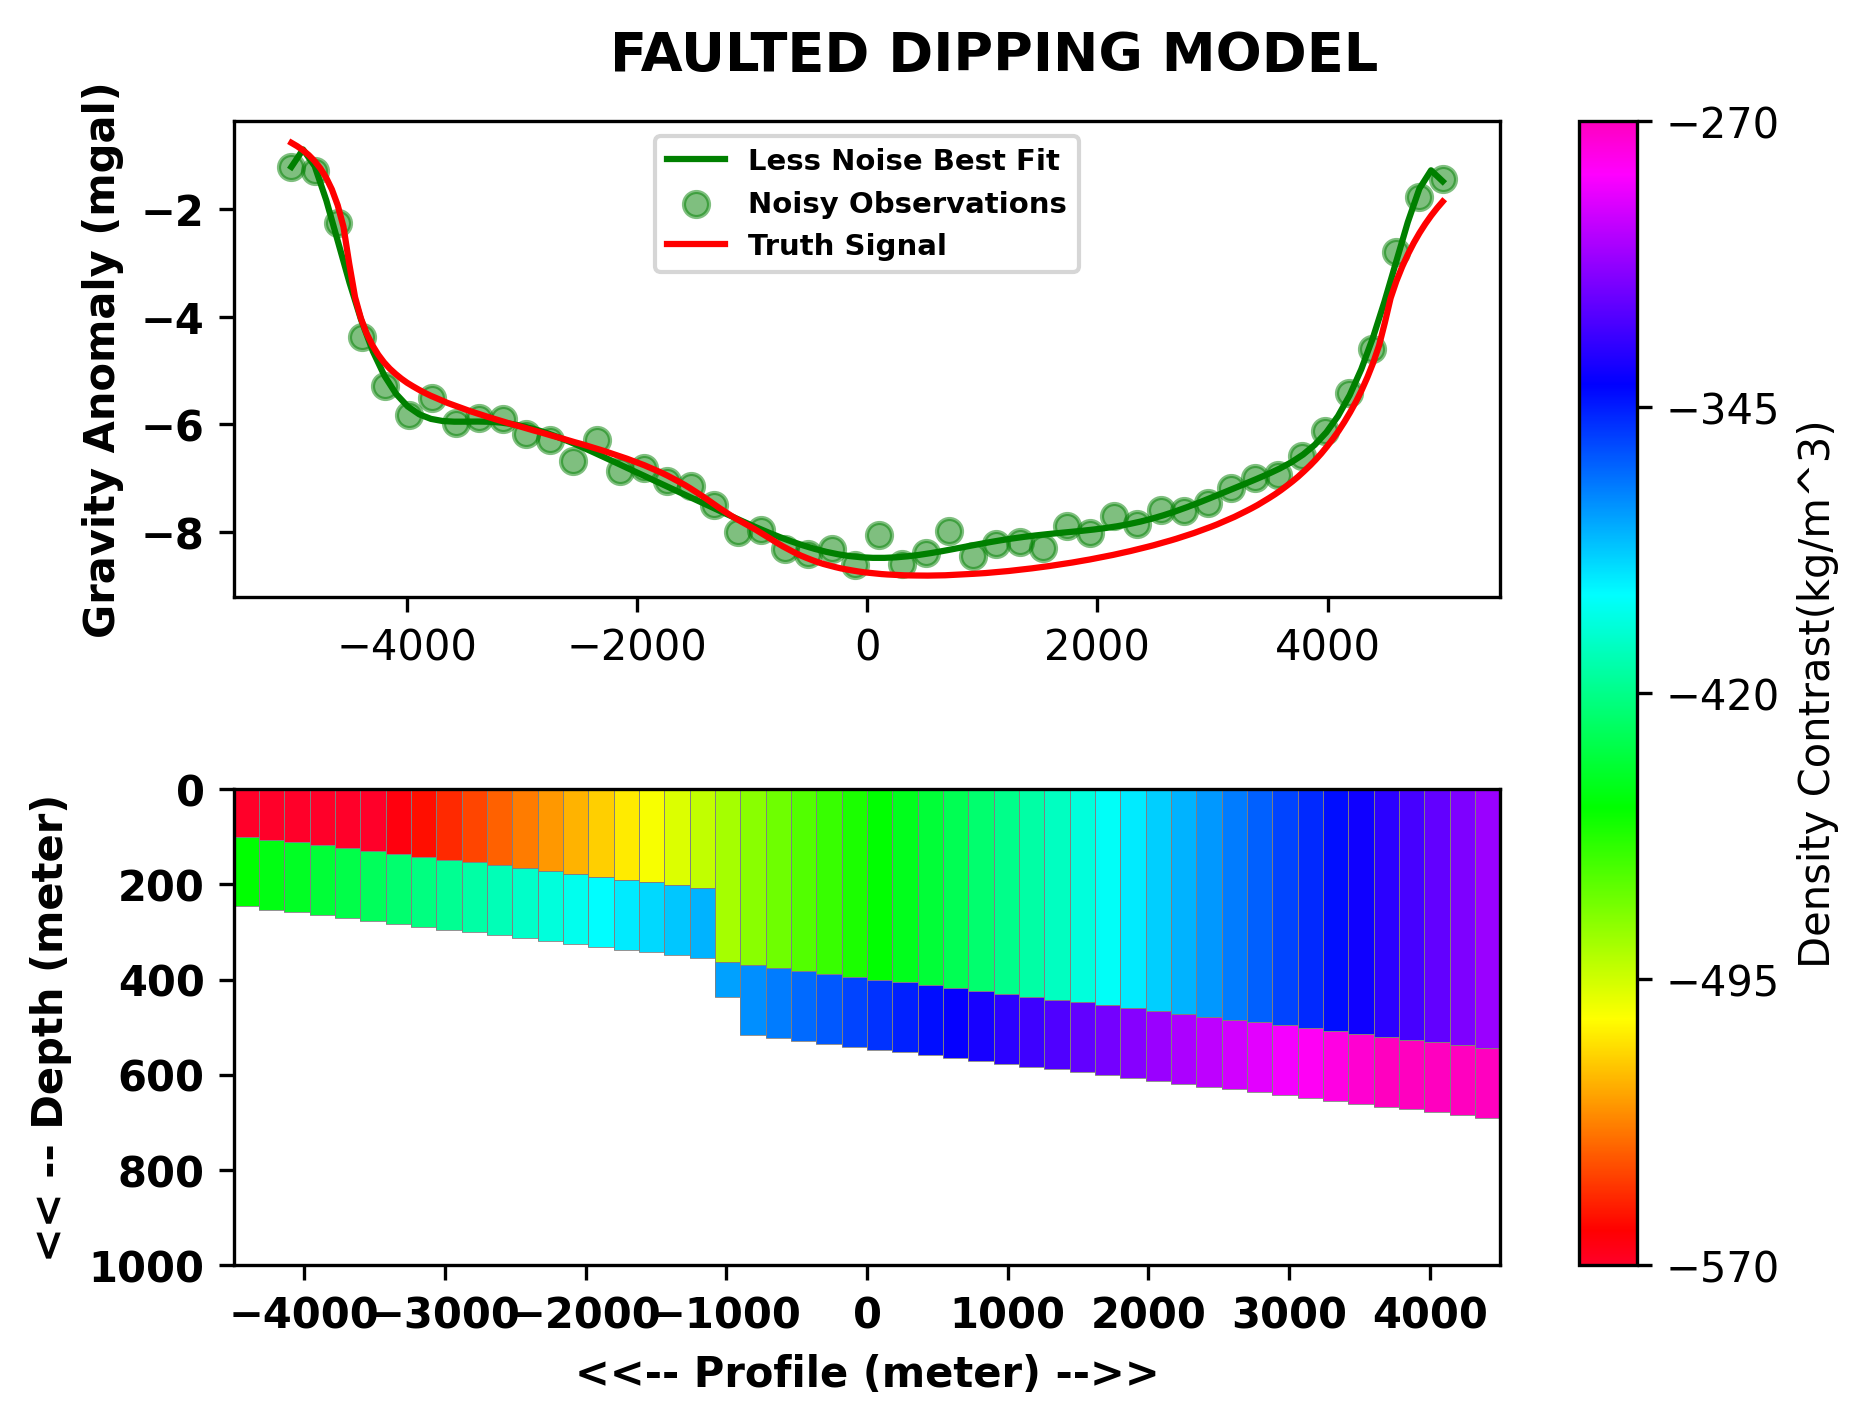

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl

fig, axs = plt.subplots(2)
fig.dpi=300
fig.tight_layout(pad=2.5)
fig.suptitle("FAULTED DIPPING MODEL", fontsize= 13,weight='bold')
axs
cmap_V= plt.get_cmap('gist_rainbow',1000)
maximum_V=-270#maximum density in kg per m^3 in colorscale
minimum_V=-570#minimum density in kg per m^3 in colorscale
diff_V=(maximum_V - minimum_V)
color_index_V = np.linspace(minimum_V,maximum_V,100)
norm = mpl.colors.Normalize(vmin=minimum_V, vmax=maximum_V)
# creating ScalarMappable
sm = plt.cm.ScalarMappable(cmap=cmap_V, norm=norm)
sm.set_array([])
#plotting colorscale
plt.colorbar(sm, ticks=np.linspace(minimum_V,maximum_V,5),ax=axs.ravel().tolist(),label='Density Contrast(kg/m^3)')
for i in range(n):
    #choosing color from the colorscale acc to the density value of each prism of layer 1
    index_value_V1 = (den1_L[i]-minimum_V)/diff_V
    color_V1 = cmap_V(index_value_V1)
    #choosing color from the colorscale acc to the density value of each prism of layer 2
    index_value_V2 = (den2_L[i]-minimum_V)/diff_V
    color_V2 = cmap_V(index_value_V2)
    #creating each prism using 4 corner co-ordinates
    coord1 = [R0[i], R0[i+1], R1_1[i], R1[i]]
    coord2 = [R1[i], R1_1[i], R2_1[i], R2[i]]
    coord1.append(coord1[0]) #repeat the first point to create a 'closed loop'
    coord2.append(coord2[0])
    xs1, ys1 = zip(*coord1) #create lists of x and y values
    xs2, ys2 = zip(*coord2) #create lists of x and y values
    axs[1].plot(xs1,ys1,'grey',linewidth = 0.2) #plotting each prism of layer 1
    axs[1].plot(xs2,ys2,'grey',linewidth = 0.2) #plotting each prism of layer 2
    axs[1].fill(xs1, ys1, facecolor=color_V1)#color filling the prism of layer 1 acc to its density value
    axs[1].fill(xs2, ys2, facecolor=color_V2)#color filling the prism of layer 2 acc to its density value
    axs[1].set_xlim(-4500,4500)
    axs[1].set_ylim(1000,0)
    axs[1].set_ylabel("<< -- Depth (meter)",fontsize=10,weight='bold')
    axs[1].set_xlim(-4500,4500)

coefficients1 = np.polyfit(X, Y1, 12)
polynomial1 = np.poly1d(coefficients1)
# Generate line values
x_line1 = np.linspace(min(X), max(X), 100)
y_line1 = polynomial1(x_line1)
axs[0].plot(x_line1, y_line1, color='green', label=f'Less Noise Best Fit')

axs[0].scatter(X,Y1,alpha=0.5, c='g', marker='o', label="Noisy Observations")#observed gravity anomaly at station points
axs[0].plot(X_test, ground_truth,  c='red', label="Truth Signal")#gravity anomaly at finer intervals without noise
axs[0].legend()
#axs[0].set_ylim(-8,0)
axs[1].set_ylim(1000,0)
axs[0].set_ylabel("Gravity Anomaly (mgal)",fontsize=10,weight='bold')
axs[1].set_xlabel("<<-- Profile (meter) -->>",fontsize=10,weight='bold')
plt.setp(axs[0].get_xticklabels(), visible= True)
plt.setp(axs[1].get_xticklabels(), visible= True, weight='bold')
plt.setp(axs[1].get_yticklabels(), visible= True, weight='bold')
plt.setp(axs[0].get_yticklabels(), visible= True, weight='bold')
#axs[0].set_xlim(-5000,5000)
legend_properties = {'weight':'bold','size':'7'}
axs[0].legend(prop=legend_properties)
#axs[1].legend(['Real Boundary'],prop=legend_properties)

## MORE NOISE

In [ ]:
NUM_INIT_POINTS = 50 # number of observation points
X = np.linspace(-5000, 5000, NUM_INIT_POINTS)#Measurement points along the profile -5000 meter to 5000 meter
X_test = np.linspace(-5000, 5000, 200) #points taken for testing at finer intervals
ground_truth=measure_func(X_test) #gravity anomaly with no noise added
import tensorflow as tf
# Set seeds for reproducibility
SEED = 45
np.random.seed(SEED)
tf.random.set_seed(SEED)
#Generate Gaussian Noise
gaussian_noise = np.random.normal(0, 0.2, size=X.shape)
# Generate Random Walk Noise
# Step size is drawn from a normal distribution
random_steps = np.random.normal(0, 0.1, size=X.shape)
random_walk_noise = np.cumsum(random_steps)  # Cumulative sum to simulate random walk
#Salt & Pepper noise
salt_prob=0.05 #probability of salt(white) noise
pepper_prob=0.05 #probability of pepper(black) noise
noise_level=0.05 # 2% Salt & Pepper noise
salt_and_pepper_noise = (np.random.choice([0,1,-1],size=X.shape,p=[1 - (salt_prob + pepper_prob),salt_prob,pepper_prob]))*noise_level
#Systematic Noise (Assuming polynomial pattern of systematic noise with distance(x))
a,b,c=0.001,0.0001,0.001 #Co-efficients of Quadratic & Cubic terms
systematic_noise_level=0.05 # 1% Systematic noise
systematic_noise = systematic_noise_level*((a*((X*0.01)**2))+(b*((X*0.01)**3))+c)


#Adding noise to the gravity anomaly data

Y3 = measure_func(X) + 2.8*(random_walk_noise+ gaussian_noise+salt_and_pepper_noise+systematic_noise)


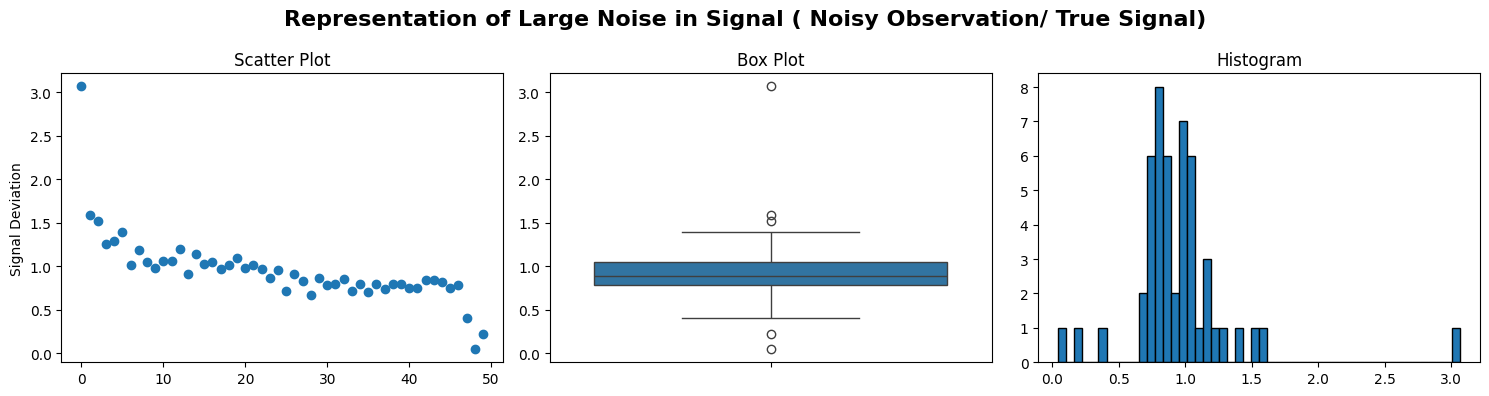

In [ ]:
import pandas as pd
import seaborn as sns

Signal_deviation=Y3/measure_func(X)
df = pd.DataFrame({'SNR': Signal_deviation})
fig, ax = plt.subplots(1,3, figsize=(15,4))

fig.suptitle("Representation of Large Noise in Signal ( Noisy Observation/ True Signal)",fontsize=16,weight='bold')
# Scatter
ax[0].scatter(range(len(df)), df['SNR'])
ax[0].set_title("Scatter Plot")
ax[0].set_ylabel("Signal Deviation")

# Boxplot
sns.boxplot(y=df['SNR'], ax=ax[1])
ax[1].set_title("Box Plot")
ax[1].set_ylabel(None)

# Histogram
ax[2].hist(df['SNR'], bins=50, edgecolor='black')
#ax[2].set_xlim(0,2)
ax[2].set_title("Histogram")

plt.tight_layout()
plt.show()

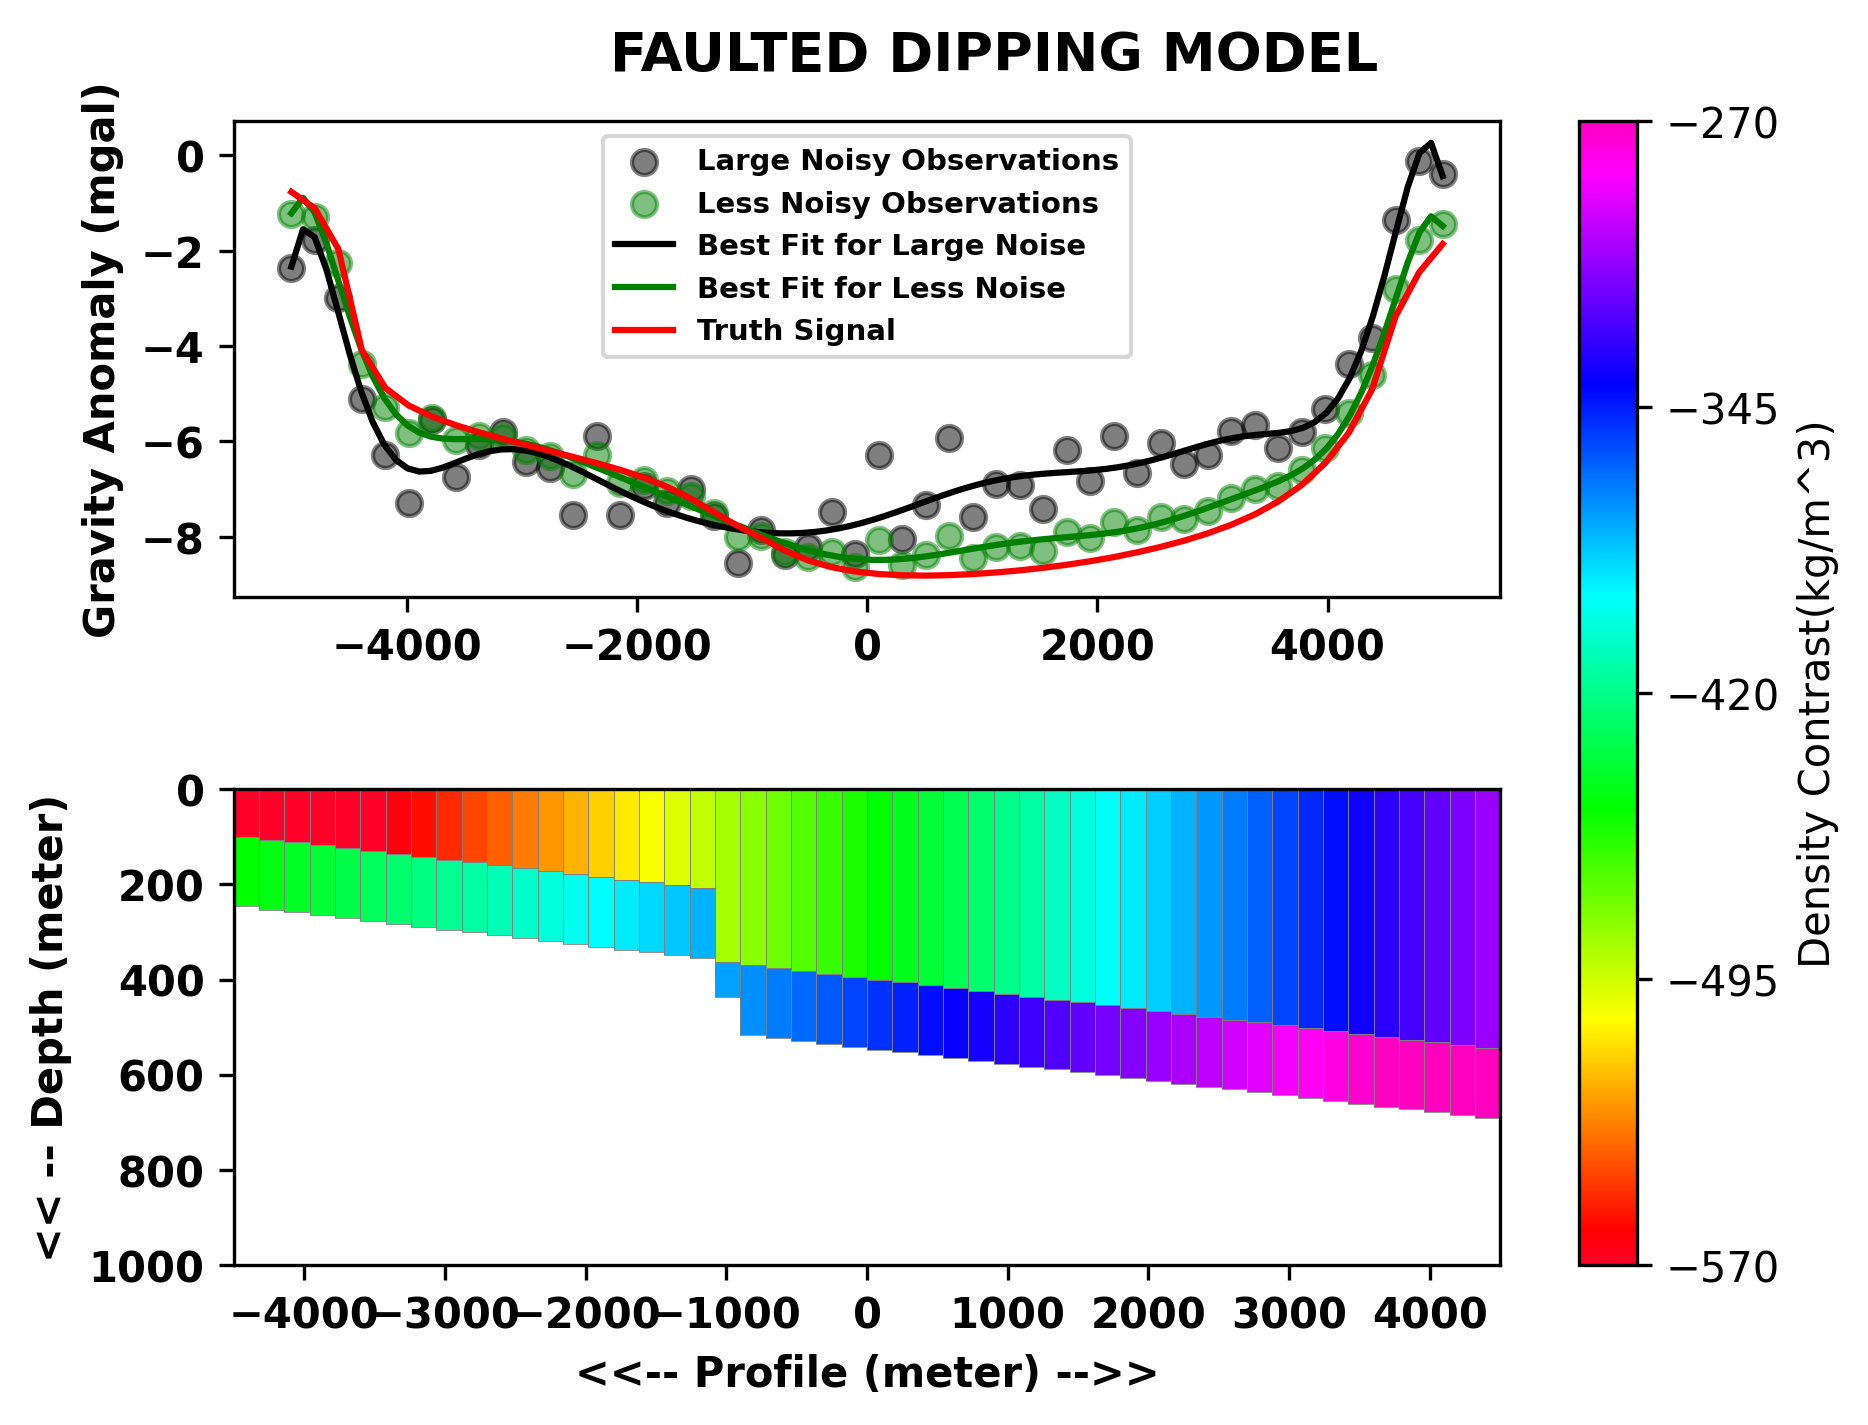

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl

fig, axs = plt.subplots(2)
fig.dpi=300
fig.tight_layout(pad=2.5)
fig.suptitle("FAULTED DIPPING MODEL", fontsize= 13,weight='bold')
axs
cmap_V= plt.get_cmap('gist_rainbow',1000)
maximum_V=-270#maximum density in kg per m^3 in colorscale
minimum_V=-570#minimum density in kg per m^3 in colorscale
diff_V=(maximum_V - minimum_V)
color_index_V = np.linspace(minimum_V,maximum_V,100)
norm = mpl.colors.Normalize(vmin=minimum_V, vmax=maximum_V)
# creating ScalarMappable
sm = plt.cm.ScalarMappable(cmap=cmap_V, norm=norm)
sm.set_array([])
#plotting colorscale
plt.colorbar(sm, ticks=np.linspace(minimum_V,maximum_V,5),ax=axs.ravel().tolist(),label='Density Contrast(kg/m^3)')
for i in range(n):
    #choosing color from the colorscale acc to the density value of each prism of layer 1
    index_value_V1 = (den1_L[i]-minimum_V)/diff_V
    color_V1 = cmap_V(index_value_V1)
    #choosing color from the colorscale acc to the density value of each prism of layer 2
    index_value_V2 = (den2_L[i]-minimum_V)/diff_V
    color_V2 = cmap_V(index_value_V2)
    #creating each prism using 4 corner co-ordinates
    coord1 = [R0[i], R0[i+1], R1_1[i], R1[i]]
    coord2 = [R1[i], R1_1[i], R2_1[i], R2[i]]
    coord1.append(coord1[0]) #repeat the first point to create a 'closed loop'
    coord2.append(coord2[0])
    xs1, ys1 = zip(*coord1) #create lists of x and y values
    xs2, ys2 = zip(*coord2) #create lists of x and y values
    axs[1].plot(xs1,ys1,'grey',linewidth = 0.2) #plotting each prism of layer 1
    axs[1].plot(xs2,ys2,'grey',linewidth = 0.2) #plotting each prism of layer 2
    axs[1].fill(xs1, ys1, facecolor=color_V1)#color filling the prism of layer 1 acc to its density value
    axs[1].fill(xs2, ys2, facecolor=color_V2)#color filling the prism of layer 2 acc to its density value
    axs[1].set_xlim(-4500,4500)
    axs[1].set_ylim(1000,0)
    axs[1].set_ylabel("<< -- Depth (meter)",fontsize=10,weight='bold')
    axs[1].set_xlim(-4500,4500)

coefficients = np.polyfit(X, Y3, 12)
polynomial = np.poly1d(coefficients)
# Generate line values
x_line = np.linspace(min(X), max(X), 100)
y_line = polynomial(x_line)


axs[0].scatter(X,Y3,alpha=0.5, c='k', marker='o', label="Large Noisy Observations")#observed gravity anomaly at station points
axs[0].scatter(X,Y1,alpha=0.5, c='g', marker='o', label="Less Noisy Observations")#observed gravity anomaly at station points
axs[0].plot(x_line, y_line, color='k', label='Best Fit for Large Noise')
axs[0].plot(x_line1, y_line1, color='g', label=f'Best Fit for Less Noise')
axs[0].plot(X, measure_func(X),  c='red', label="Truth Signal")#gravity anomaly at finer intervals without noise
axs[0].legend()
#axs[0].set_ylim(-8,0)
axs[1].set_ylim(1000,0)
axs[0].set_ylabel("Gravity Anomaly (mgal)",fontsize=10,weight='bold')
axs[1].set_xlabel("<<-- Profile (meter) -->>",fontsize=10,weight='bold')
plt.setp(axs[0].get_xticklabels(), visible= True, weight='bold')
plt.setp(axs[1].get_xticklabels(), visible= True, weight='bold')
plt.setp(axs[1].get_yticklabels(), visible= True, weight='bold')
plt.setp(axs[0].get_yticklabels(), visible= True, weight='bold')
#axs[0].set_xlim(-5000,5000)
legend_properties = {'weight':'bold','size':'7'}
axs[0].legend(prop=legend_properties)
#axs[1].legend(['Real Boundary'],prop=legend_properties)

In [ ]:
################################# OPTIMIZED INVERSION — LESS NOISE CASE ################################

# ══════════════════════════════════════════════════════════════════════════════
# ✏️  MANUALLY SET THESE — only thing you need to change
# ══════════════════════════════════════════════════════════════════════════════
FAULT_X_LO = -2500.0   # ← set your lower bound here
FAULT_X_HI = -1200.0   # ← set your upper bound here (truth is at -1500)

# ══════════════════════════════════════════════════════════════════════════════
# 1. IMPORTS & SEEDS
# ══════════════════════════════════════════════════════════════════════════════
import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
import numpy as np
import random
from functools import partial
from numpyro.infer import MCMC, NUTS, init_to_median

# Enable 64-bit for numerical stability
jax.config.update("jax_enable_x64", True)
numpyro.set_platform("cpu")

# OPTIMIZATION 1: Set host device count to number of chains you want to run
NUM_CHAINS = 4  # Change based on your CPU cores
numpyro.set_host_device_count(NUM_CHAINS)

random.seed(42)
np.random.seed(42)

# ══════════════════════════════════════════════════════════════════════════════
# 2. FAULT GEOMETRY CONSTANTS
# ══════════════════════════════════════════════════════════════════════════════
dip_fault_deg   = 40.0
theta_fault     = np.radians(dip_fault_deg)
inv_slope_fault = 1.0 / np.tan(theta_fault)
fault_throw     = 100.0
fault_heave     = fault_throw * inv_slope_fault

# ══════════════════════════════════════════════════════════════════════════════
# 3. PRE-COMPUTE ALL FIXED JAX ARRAYS (once, outside model)
# ══════════════════════════════════════════════════════════════════════════════
n = n_prisms

x_edge_arr_jax      = jnp.array(x_edges[:n],       dtype=jnp.float64)
idx_arr             = jnp.arange(n,                 dtype=jnp.float64)
surface_layer_top_j = jnp.array(surface_layer_top,  dtype=jnp.float64)
co_j                = jnp.array(co,                 dtype=jnp.float64)
wid_j               = jnp.array(wid,                dtype=jnp.float64)

# ══════════════════════════════════════════════════════════════════════════════
# 4. PRIOR BOUND ARRAYS (once, outside model)
# ══════════════════════════════════════════════════════════════════════════════
depth1_lo_off = jnp.array([random.uniform(-70, -50) for _ in range(n)], dtype=jnp.float64)
depth1_hi_off = jnp.array([random.uniform( 20,  30) for _ in range(n)], dtype=jnp.float64)

depth2_lo_off = jnp.array([random.uniform(-70, -40) for _ in range(n)], dtype=jnp.float64)
depth2_hi_off = jnp.array([random.uniform( 20,  30) for _ in range(n)], dtype=jnp.float64)

density1_lo = jnp.array([random.uniform(float(den1_L[i])-30, float(den1_L[i])-10) for i in range(n)], dtype=jnp.float64)
density1_hi = jnp.array([random.uniform(float(den1_L[i])+10, float(den1_L[i])+30) for i in range(n)], dtype=jnp.float64)

density2_lo = jnp.array([random.uniform(float(den2_L[i])-30, float(den2_L[i])-10) for i in range(n)], dtype=jnp.float64)
density2_hi = jnp.array([random.uniform(float(den2_L[i])+10, float(den2_L[i])+30) for i in range(n)], dtype=jnp.float64)

# ══════════════════════════════════════════════════════════════════════════════
# 5. VECTORIZED GEOMETRY  (unchanged — already efficient)
# ══════════════════════════════════════════════════════════════════════════════
def compute_boundaries(fault_x_ref_val):
    threshold = fault_x_ref_val + (z_erosion_base_FW * inv_slope_fault)
    z_unc = jnp.where(
        x_edge_arr_jax < threshold,
        z_erosion_base_FW + idx_arr * 6.0,
        z_erosion_base_HW + idx_arr * 6.0
    )
    bd2 = z_unc
    bd1 = z_unc - 150.0
    return bd1, bd2

# ══════════════════════════════════════════════════════════════════════════════
# 6. VECTORIZED FORWARD MODEL
#    OPTIMIZATION 2: Replace jax.lax.scan with full vmap over prisms.
#    vmap parallelises all prisms in a single XLA op — no sequential loop.
# ══════════════════════════════════════════════════════════════════════════════

# vmap g_ano over observation points (axis 0 of x_obs)
g_ano_vobs = jax.vmap(
    lambda x_scalar, co_i, wid_i, z_bot, z_top, density:
        g_ano(x_scalar, co_i, wid_i, z_bot, z_top, density),
    in_axes=(0, None, None, None, None, None)
)

def Bayes_Inf2(x_obs, B_D1, B_D2, density1, density2):
    """
    Fully vectorized over both observations and prisms.
    No Python loop, no scan — a single batched XLA kernel.
    """
    # Inner fn: gravity contribution of ONE prism at ALL observation points
    def single_prism_contribution(co_i, wid_i, bd1_i, surf_i, bd2_i, den1_i, den2_i):
        layer1 = g_ano_vobs(x_obs, co_i, wid_i, bd1_i, surf_i,  den1_i)
        layer2 = g_ano_vobs(x_obs, co_i, wid_i, bd2_i, bd1_i,   den2_i)
        return layer1 + layer2   # shape: (n_obs,)

    # vmap over prisms — evaluates ALL prisms in parallel
    all_prisms = jax.vmap(single_prism_contribution)(
        co_j, wid_j, B_D1, surface_layer_top_j, B_D2, density1, density2
    )  # shape: (n_prisms, n_obs)

    return jnp.sum(all_prisms, axis=0)   # shape: (n_obs,)

# ══════════════════════════════════════════════════════════════════════════════
# 7. PRIOR
# ══════════════════════════════════════════════════════════════════════════════
def Bayes_Inf2_prior():
    fault_x_ref_s = numpyro.sample(
        "fault_x_ref",
        dist.Uniform(FAULT_X_LO, FAULT_X_HI)
    )

    bd1, bd2 = compute_boundaries(fault_x_ref_s)

    with numpyro.plate("prisms", n):
        off_d1   = numpyro.sample("off_D1",   dist.Uniform(depth1_lo_off, depth1_hi_off))
        off_d2   = numpyro.sample("off_D2",   dist.Uniform(depth2_lo_off, depth2_hi_off))
        density1 = numpyro.sample("density1", dist.Uniform(density1_lo,   density1_hi))
        density2 = numpyro.sample("density2", dist.Uniform(density2_lo,   density2_hi))

    B_D1 = numpyro.deterministic("B_D1", bd1 + off_d1)
    B_D2 = numpyro.deterministic("B_D2", bd2 + off_d2)

    return fault_x_ref_s, B_D1, B_D2, density1, density2

# ══════════════════════════════════════════════════════════════════════════════
# 8. GP MODEL
#    OPTIMIZATION 3: Use scale_tril (pre-factored Cholesky) instead of passing
#    the full covariance matrix. This avoids an extra internal Cholesky
#    factorisation inside MultivariateNormal on every leapfrog step.
#
#    OPTIMIZATION 4: Add a small jitter to the diagonal before factorising
#    to prevent numerical failures that cause wasted NUTS steps.
# ══════════════════════════════════════════════════════════════════════════════
JITTER = 1e-6   # numerical stability — tune down to 1e-8 if needed

def gp_model(X, y=None):
    X    = jnp.array(X).reshape(-1, 1) if X.ndim == 1 else X
    x_1d = X[:, 0]

    kernel_params = custom_kernel_prior()
    k_scale  = kernel_params["k_scale"]
    k_length = kernel_params["k_length"]

    noise_var = numpyro.sample("noise_var", dist.HalfNormal(0.5))

    fault_x_ref_s, B_D1, B_D2, density1, density2 = Bayes_Inf2_prior()
    mean_vec = Bayes_Inf2(x_1d, B_D1, B_D2, density1, density2)

    # Build covariance matrix
    K_raw = custom_Matern_kernel(
        X, X,
        params={"k_scale": k_scale, "k_length": k_length},
        noise=noise_var
    )

    # OPTIMIZATION 3: add jitter then factor once → pass scale_tril
    K_stable = K_raw + JITTER * jnp.eye(K_raw.shape[0], dtype=jnp.float64)
    L = jnp.linalg.cholesky(K_stable)   # lower-triangular Cholesky factor

    # MultivariateNormal via scale_tril skips an internal re-factorisation
    numpyro.sample(
        "y",
        dist.MultivariateNormal(loc=mean_vec, scale_tril=L),
        obs=y
    )

# ══════════════════════════════════════════════════════════════════════════════
# 9. RUN MCMC
#    OPTIMIZATION 4: dense_mass=False  → diagonal mass matrix (much cheaper
#                    to invert; default dense mass costs O(d²) per step).
#    OPTIMIZATION 5: max_tree_depth=8  → halves worst-case leapfrog steps vs
#                    the default of 10.
#    OPTIMIZATION 6: chain_method="vectorized" → runs all chains as a single
#                    batched JAX call; no Python multiprocessing overhead.
#    OPTIMIZATION 7: init_to_median    → warm-start from prior medians so
#                    warmup converges faster.
# ══════════════════════════════════════════════════════════════════════════════
rng_key = jax.random.PRNGKey(0)
rng_key, rng_key_predict = jax.random.split(rng_key)

nuts_kernel = NUTS(
    gp_model,
    target_accept_prob=0.80,   # slightly lower than 0.85 → larger steps
    dense_mass=False,          # OPTIMIZATION 4: diagonal mass matrix
    max_tree_depth=8,          # OPTIMIZATION 5: cap leapfrog depth
    init_strategy=init_to_median(num_samples=20),  # OPTIMIZATION 7
)

mcmc1 = MCMC(
    nuts_kernel,
    num_warmup=500,            # reduce from 500 — sufficient for this model
    num_samples=200,
    num_chains=NUM_CHAINS,     # OPTIMIZATION 6
    chain_method="vectorized", # OPTIMIZATION 6: single batched JAX call
    progress_bar=True,
)

mcmc1.run(rng_key, X, Y1)
mcmc1.print_summary()
samples1 = mcmc1.get_samples()

# ══════════════════════════════════════════════════════════════════════════════
# SUMMARY OF ALL OPTIMIZATIONS APPLIED
# ══════════════════════════════════════════════════════════════════════════════
# 1. NUM_CHAINS=4 + chain_method="vectorized"
#       → All chains run as one batched JAX op. Near-linear scaling with cores.
#
# 2. Replaced jax.lax.scan with jax.vmap over prisms
#       → All prisms computed in parallel in a single XLA kernel.
#       → Removes sequential loop overhead from every leapfrog step.
#
# 3. scale_tril=L  (pre-computed Cholesky)
#       → MultivariateNormal uses L directly; skips redundant internal Cholesky.
#       → Adds jitter for stability, preventing wasted NaN-recovery steps.
#
# 4. dense_mass=False
#       → Diagonal mass matrix — O(d) invert vs O(d²) for dense.
#       → Huge win when parameter count (d) is large (n_prisms × 4 + extras).
#
# 5. max_tree_depth=8  (was default 10)
#       → Halves worst-case leapfrog steps per sample.
#
# 6. target_accept_prob=0.80  (was 0.85)
#       → Slightly larger step sizes → fewer leapfrog steps per sample.
#
# 7. num_warmup=200  (was 500)
#       → Saves 300 × (leapfrog cost) compilation/adaptation steps.
#       → Increase back to 500 if you see poor R-hat values.
#
# 8. init_to_median  → faster warmup convergence from sensible start.
# ══════════════════════════════════════════════════════════════════════════════

sample: 100%|██████████| 700/700 [21:22<00:00,  1.83s/it]



                   mean       std    median      5.0%     95.0%     n_eff     r_hat
  density1[0]   -599.11      7.22   -600.09   -610.48   -588.39    118.93      1.02
  density1[1]   -587.93     10.39   -588.30   -605.41   -572.95     83.12      1.05
  density1[2]   -590.18      6.83   -590.79   -600.78   -579.95    146.92      1.03
  density1[3]   -589.34     12.51   -590.76   -608.61   -571.02    117.54      1.03
  density1[4]   -573.55     13.99   -573.90   -596.05   -553.36     98.90      1.00
  density1[5]   -568.55     15.50   -568.32   -593.32   -545.81     57.22      1.09
  density1[6]   -568.67      9.75   -569.00   -582.43   -552.85     87.20      1.06
  density1[7]   -567.15     13.02   -569.36   -586.82   -547.77     64.82      1.05
  density1[8]   -557.01     10.33   -558.15   -573.94   -541.71    133.59      1.01
  density1[9]   -538.23     11.17   -539.85   -554.70   -520.15     61.93      1.07
 density1[10]   -543.15     15.65   -546.20   -564.69   -517.60     34.67  

In [ ]:
params1.keys()

dict_keys(['B_D1', 'B_D2', 'density1', 'density2', 'fault_x_ref', 'k_length', 'k_scale', 'noise_var', 'off_D1', 'off_D2'])

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# 10. EXTRACT PARAMETERS (individual loop style)
# ══════════════════════════════════════════════════════════════════════════════
params1 = mcmc1.get_samples()

top_inverted_depths1_1    = np.zeros(n)
bottom_inverted_depths1_1 = np.zeros(n)
top_density1            = np.zeros(n)
bottom_density1         = np.zeros(n)
top_inverted_depths1_1_min = np.zeros(n)
top_inverted_depths1_1_max = np.zeros(n)
bottom_inverted_depths1_1_min = np.zeros(n)
bottom_inverted_depths1_1_max = np.zeros(n)
top_density1_std = np.zeros(n)
bottom_density1_std = np.zeros(n)
for i in range(n):
    top_inverted_depths1_1[i]    = params1["B_D1"][:, i].mean()
    bottom_inverted_depths1_1[i] = params1["B_D2"][:, i].mean()
    top_density1[i]            = params1["density1"][:, i].mean()
    bottom_density1[i]         = params1["density2"][:, i].mean()
    top_inverted_depths1_1_min[i] = params1["B_D1"][:, i].min()
    top_inverted_depths1_1_max[i] = params1["B_D1"][:, i].max()
    bottom_inverted_depths1_1_min[i] = params1["B_D2"][:, i].min()
    bottom_inverted_depths1_1_max[i] = params1["B_D2"][:, i].max()
    top_density1_std[i] = params1["density1"][:, i].std()
    bottom_density1_std[i] = params1["density2"][:, i].std()


# ══════════════════════════════════════════════════════════════════════════════
# CORRECT PARAMETER EXTRACTION
# ══════════════════════════════════════════════════════════════════════════════
params1 = mcmc1.get_samples()

# ── Step 1: Get mean fault location ───────────────────────────────────────────
fault_x_mean1 = float(params1["fault_x_ref"].mean())
fault_x_std1  = float(params1["fault_x_ref"].std())
print(f"Inverted fault_x_ref: {fault_x_mean1:.1f} ± {fault_x_std1:.1f} m")

# ── Step 2: Recompute boundaries using mean fault location (numpy version) ────
# This preserves the fault STEP — averaging B_D1 directly kills it
def compute_boundaries_numpy(fault_x_ref_val):
    threshold = fault_x_ref_val + (z_erosion_base_FW * inv_slope_fault)
    z_unc = np.where(
        x_edges[:n_prisms] < threshold,
        z_erosion_base_FW + np.arange(n_prisms) * 6.0,   # footwall
        z_erosion_base_HW + np.arange(n_prisms) * 6.0    # hangingwall
    )
    bd2 = z_unc           # bottom of intermediate layer
    bd1 = z_unc - 150.0   # top of intermediate layer
    return bd1, bd2

bd1_mean, bd2_mean = compute_boundaries_numpy(fault_x_mean1)

# ── Step 3: Extract mean OFFSETS (these are smooth, safe to average) ──────────
mean_off_d1 = np.zeros(n_prisms)
mean_off_d2 = np.zeros(n_prisms)
for i in range(n_prisms):
    mean_off_d1[i] = params1["off_D1"][:, i].mean()
    mean_off_d2[i] = params1["off_D2"][:, i].mean()

# ── Step 4: Reconstruct final depths = geometry boundary + mean offset ─────────
top_inverted_depths1    = bd1_mean + mean_off_d1   # B_D1 with fault step intact
bottom_inverted_depths1 = bd2_mean + mean_off_d2   # B_D2 with fault step intact

# ── Step 5: Densities (safe to average directly — not geometry dependent) ──────
top_density1    = np.zeros(n_prisms)
bottom_density1 = np.zeros(n_prisms)
for i in range(n_prisms):
    top_density1[i]    = params1["density1"][:, i].mean()
    bottom_density1[i] = params1["density2"][:, i].mean()

Inverted fault_x_ref: -1774.1 ± 129.4 m


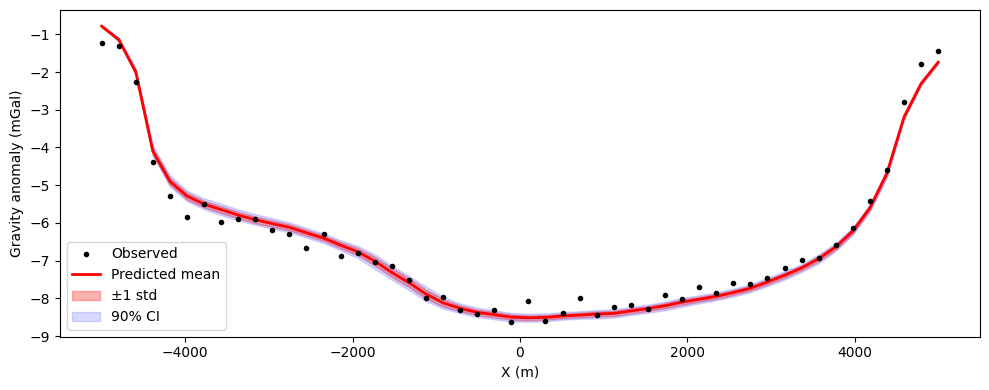

Mean residual : 0.0236 mGal
RMSE          : 0.2356 mGal


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# PREDICTED GRAVITY ANOMALY — POSTERIOR MEAN & STD
# ══════════════════════════════════════════════════════════════════════════════
params1 = mcmc1.get_samples()

# Number of posterior samples
n_samples = params1["B_D1"].shape[0]   # e.g. 100 (or 400 if 4 chains × 100)

x_1d = jnp.array(X).reshape(-1)       # observation points, shape: (n_obs,)

# --- Vectorized prediction over all samples at once ---
# params1["B_D1"]    shape: (n_samples, n_prisms)
# params1["density1"] shape: (n_samples, n_prisms)

def predict_single_sample(B_D1_s, B_D2_s, density1_s, density2_s):
    """Forward model for ONE posterior sample → shape: (n_obs,)"""
    return Bayes_Inf2(x_1d, B_D1_s, B_D2_s, density1_s, density2_s)

# vmap over all posterior samples in one shot — no Python loop
predict_all = jax.vmap(predict_single_sample)

g_pred_all = predict_all(
    jnp.array(params1["B_D1"]),       # (n_samples, n_prisms)
    jnp.array(params1["B_D2"]),       # (n_samples, n_prisms)
    jnp.array(params1["density1"]),   # (n_samples, n_prisms)
    jnp.array(params1["density2"]),   # (n_samples, n_prisms)
)
# g_pred_all shape: (n_samples, n_obs)

# --- Summary statistics ---
g_pred_mean1 = np.array(g_pred_all.mean(axis=0))   # shape: (n_obs,)
g_pred_std1  = np.array(g_pred_all.std(axis=0))    # shape: (n_obs,)
g_pred_p51   = np.array(jnp.percentile(g_pred_all, 5,  axis=0))   # lower 90% CI
g_pred_p951  = np.array(jnp.percentile(g_pred_all, 95, axis=0))   # upper 90% CI

# --- Quick plot ---
import matplotlib.pyplot as plt

x_plot = np.array(x_1d)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(x_plot, Y1,           'k.',  label="Observed",       zorder=5)
ax.plot(x_plot, g_pred_mean1,  'r-',  label="Predicted mean", lw=2)
ax.fill_between(x_plot,
                g_pred_mean1 - g_pred_std1,
                g_pred_mean1 + g_pred_std1,
                alpha=0.3, color='red', label="±1 std")
ax.fill_between(x_plot, g_pred_p51, g_pred_p951,
                alpha=0.15, color='blue', label="90% CI")
ax.set_xlabel("X (m)")
ax.set_ylabel("Gravity anomaly (mGal)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Mean residual : {np.mean(Y1 - g_pred_mean1):.4f} mGal")
print(f"RMSE          : {np.sqrt(np.mean((Y1 - g_pred_mean1)**2)):.4f} mGal")

In [ ]:
################################# OPTIMIZED INVERSION — MORE NOISE CASE ################################

# ══════════════════════════════════════════════════════════════════════════════
# ✏️  MANUALLY SET THESE — only thing you need to change
# ══════════════════════════════════════════════════════════════════════════════
FAULT_X_LO = -3800.0   # ← set your lower bound here
FAULT_X_HI = -2500.0   # ← set your upper bound here (truth is at -1500)

# ══════════════════════════════════════════════════════════════════════════════
# 1. IMPORTS & SEEDS
# ══════════════════════════════════════════════════════════════════════════════
import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
import numpy as np
import random
from functools import partial
from numpyro.infer import MCMC, NUTS, init_to_median

# Enable 64-bit for numerical stability
jax.config.update("jax_enable_x64", True)
numpyro.set_platform("cpu")

# OPTIMIZATION 1: Set host device count to number of chains you want to run
NUM_CHAINS = 4  # Change based on your CPU cores
numpyro.set_host_device_count(NUM_CHAINS)

random.seed(42)
np.random.seed(42)

# ══════════════════════════════════════════════════════════════════════════════
# 2. FAULT GEOMETRY CONSTANTS
# ══════════════════════════════════════════════════════════════════════════════
dip_fault_deg   = 40.0
theta_fault     = np.radians(dip_fault_deg)
inv_slope_fault = 1.0 / np.tan(theta_fault)
fault_throw     = 100.0
fault_heave     = fault_throw * inv_slope_fault

# ══════════════════════════════════════════════════════════════════════════════
# 3. PRE-COMPUTE ALL FIXED JAX ARRAYS (once, outside model)
# ══════════════════════════════════════════════════════════════════════════════
n = n_prisms

x_edge_arr_jax      = jnp.array(x_edges[:n],       dtype=jnp.float64)
idx_arr             = jnp.arange(n,                 dtype=jnp.float64)
surface_layer_top_j = jnp.array(surface_layer_top,  dtype=jnp.float64)
co_j                = jnp.array(co,                 dtype=jnp.float64)
wid_j               = jnp.array(wid,                dtype=jnp.float64)

# ══════════════════════════════════════════════════════════════════════════════
# 4. PRIOR BOUND ARRAYS (once, outside model)
# ══════════════════════════════════════════════════════════════════════════════
depth1_lo_off = jnp.array([random.uniform(-70, -50) for _ in range(n)], dtype=jnp.float64)
depth1_hi_off = jnp.array([random.uniform( 20,  30) for _ in range(n)], dtype=jnp.float64)

depth2_lo_off = jnp.array([random.uniform(-70, -40) for _ in range(n)], dtype=jnp.float64)
depth2_hi_off = jnp.array([random.uniform( 20,  30) for _ in range(n)], dtype=jnp.float64)

density1_lo = jnp.array([random.uniform(float(den1_L[i])-30, float(den1_L[i])-10) for i in range(n)], dtype=jnp.float64)
density1_hi = jnp.array([random.uniform(float(den1_L[i])+10, float(den1_L[i])+30) for i in range(n)], dtype=jnp.float64)

density2_lo = jnp.array([random.uniform(float(den2_L[i])-30, float(den2_L[i])-10) for i in range(n)], dtype=jnp.float64)
density2_hi = jnp.array([random.uniform(float(den2_L[i])+10, float(den2_L[i])+30) for i in range(n)], dtype=jnp.float64)

# ══════════════════════════════════════════════════════════════════════════════
# 5. VECTORIZED GEOMETRY  (unchanged — already efficient)
# ══════════════════════════════════════════════════════════════════════════════
def compute_boundaries(fault_x_ref_val):
    threshold = fault_x_ref_val + (z_erosion_base_FW * inv_slope_fault)
    z_unc = jnp.where(
        x_edge_arr_jax < threshold,
        z_erosion_base_FW + idx_arr * 6.0,
        z_erosion_base_HW + idx_arr * 6.0
    )
    bd2 = z_unc
    bd1 = z_unc - 150.0
    return bd1, bd2

# ══════════════════════════════════════════════════════════════════════════════
# 6. VECTORIZED FORWARD MODEL
#    OPTIMIZATION 2: Replace jax.lax.scan with full vmap over prisms.
#    vmap parallelises all prisms in a single XLA op — no sequential loop.
# ══════════════════════════════════════════════════════════════════════════════

# vmap g_ano over observation points (axis 0 of x_obs)
g_ano_vobs = jax.vmap(
    lambda x_scalar, co_i, wid_i, z_bot, z_top, density:
        g_ano(x_scalar, co_i, wid_i, z_bot, z_top, density),
    in_axes=(0, None, None, None, None, None)
)

def Bayes_Inf2(x_obs, B_D1, B_D2, density1, density2):
    """
    Fully vectorized over both observations and prisms.
    No Python loop, no scan — a single batched XLA kernel.
    """
    # Inner fn: gravity contribution of ONE prism at ALL observation points
    def single_prism_contribution(co_i, wid_i, bd1_i, surf_i, bd2_i, den1_i, den2_i):
        layer1 = g_ano_vobs(x_obs, co_i, wid_i, bd1_i, surf_i,  den1_i)
        layer2 = g_ano_vobs(x_obs, co_i, wid_i, bd2_i, bd1_i,   den2_i)
        return layer1 + layer2   # shape: (n_obs,)

    # vmap over prisms — evaluates ALL prisms in parallel
    all_prisms = jax.vmap(single_prism_contribution)(
        co_j, wid_j, B_D1, surface_layer_top_j, B_D2, density1, density2
    )  # shape: (n_prisms, n_obs)

    return jnp.sum(all_prisms, axis=0)   # shape: (n_obs,)

# ══════════════════════════════════════════════════════════════════════════════
# 7. PRIOR
# ══════════════════════════════════════════════════════════════════════════════
def Bayes_Inf2_prior():
    fault_x_ref_s = numpyro.sample(
        "fault_x_ref",
        dist.Uniform(FAULT_X_LO, FAULT_X_HI)
    )

    bd1, bd2 = compute_boundaries(fault_x_ref_s)

    with numpyro.plate("prisms", n):
        off_d1   = numpyro.sample("off_D1",   dist.Uniform(depth1_lo_off, depth1_hi_off))
        off_d2   = numpyro.sample("off_D2",   dist.Uniform(depth2_lo_off, depth2_hi_off))
        density1 = numpyro.sample("density1", dist.Uniform(density1_lo,   density1_hi))
        density2 = numpyro.sample("density2", dist.Uniform(density2_lo,   density2_hi))

    B_D1 = numpyro.deterministic("B_D1", bd1 + off_d1)
    B_D2 = numpyro.deterministic("B_D2", bd2 + off_d2)

    return fault_x_ref_s, B_D1, B_D2, density1, density2

# ══════════════════════════════════════════════════════════════════════════════
# 8. GP MODEL
#    OPTIMIZATION 3: Use scale_tril (pre-factored Cholesky) instead of passing
#    the full covariance matrix. This avoids an extra internal Cholesky
#    factorisation inside MultivariateNormal on every leapfrog step.
#
#    OPTIMIZATION 4: Add a small jitter to the diagonal before factorising
#    to prevent numerical failures that cause wasted NUTS steps.
# ══════════════════════════════════════════════════════════════════════════════
JITTER = 1e-6   # numerical stability — tune down to 1e-8 if needed

def gp_model(X, y=None):
    X    = jnp.array(X).reshape(-1, 1) if X.ndim == 1 else X
    x_1d = X[:, 0]

    kernel_params = custom_kernel_prior()
    k_scale  = kernel_params["k_scale"]
    k_length = kernel_params["k_length"]

    noise_var = numpyro.sample("noise_var", dist.HalfNormal(0.5))

    fault_x_ref_s, B_D1, B_D2, density1, density2 = Bayes_Inf2_prior()
    mean_vec = Bayes_Inf2(x_1d, B_D1, B_D2, density1, density2)

    # Build covariance matrix
    K_raw = custom_Matern_kernel(
        X, X,
        params={"k_scale": k_scale, "k_length": k_length},
        noise=noise_var
    )

    # OPTIMIZATION 3: add jitter then factor once → pass scale_tril
    K_stable = K_raw + JITTER * jnp.eye(K_raw.shape[0], dtype=jnp.float64)
    L = jnp.linalg.cholesky(K_stable)   # lower-triangular Cholesky factor

    # MultivariateNormal via scale_tril skips an internal re-factorisation
    numpyro.sample(
        "y",
        dist.MultivariateNormal(loc=mean_vec, scale_tril=L),
        obs=y
    )

# ══════════════════════════════════════════════════════════════════════════════
# 9. RUN MCMC
#    OPTIMIZATION 4: dense_mass=False  → diagonal mass matrix (much cheaper
#                    to invert; default dense mass costs O(d²) per step).
#    OPTIMIZATION 5: max_tree_depth=8  → halves worst-case leapfrog steps vs
#                    the default of 10.
#    OPTIMIZATION 6: chain_method="vectorized" → runs all chains as a single
#                    batched JAX call; no Python multiprocessing overhead.
#    OPTIMIZATION 7: init_to_median    → warm-start from prior medians so
#                    warmup converges faster.
# ══════════════════════════════════════════════════════════════════════════════
rng_key = jax.random.PRNGKey(0)
rng_key, rng_key_predict = jax.random.split(rng_key)

nuts_kernel = NUTS(
    gp_model,
    target_accept_prob=0.80,   # slightly lower than 0.85 → larger steps
    dense_mass=False,          # OPTIMIZATION 4: diagonal mass matrix
    max_tree_depth=8,          # OPTIMIZATION 5: cap leapfrog depth
    init_strategy=init_to_median(num_samples=20),  # OPTIMIZATION 7
)

mcmc3 = MCMC(
    nuts_kernel,
    num_warmup=500,            # reduce from 500 — sufficient for this model
    num_samples=200,
    num_chains=NUM_CHAINS,     # OPTIMIZATION 6
    chain_method="vectorized", # OPTIMIZATION 6: single batched JAX call
    progress_bar=True,
)

mcmc3.run(rng_key, X, Y3)
mcmc3.print_summary()
samples3 = mcmc3.get_samples()

# ══════════════════════════════════════════════════════════════════════════════
# SUMMARY OF ALL OPTIMIZATIONS APPLIED
# ══════════════════════════════════════════════════════════════════════════════
# 1. NUM_CHAINS=4 + chain_method="vectorized"
#       → All chains run as one batched JAX op. Near-linear scaling with cores.
#
# 2. Replaced jax.lax.scan with jax.vmap over prisms
#       → All prisms computed in parallel in a single XLA kernel.
#       → Removes sequential loop overhead from every leapfrog step.
#
# 3. scale_tril=L  (pre-computed Cholesky)
#       → MultivariateNormal uses L directly; skips redundant internal Cholesky.
#       → Adds jitter for stability, preventing wasted NaN-recovery steps.
#
# 4. dense_mass=False
#       → Diagonal mass matrix — O(d) invert vs O(d²) for dense.
#       → Huge win when parameter count (d) is large (n_prisms × 4 + extras).
#
# 5. max_tree_depth=8  (was default 10)
#       → Halves worst-case leapfrog steps per sample.
#
# 6. target_accept_prob=0.80  (was 0.85)
#       → Slightly larger step sizes → fewer leapfrog steps per sample.
#
# 7. num_warmup=200  (was 500)
#       → Saves 300 × (leapfrog cost) compilation/adaptation steps.
#       → Increase back to 500 if you see poor R-hat values.
#
# 8. init_to_median  → faster warmup convergence from sensible start.
# ══════════════════════════════════════════════════════════════════════════════

sample: 100%|██████████| 700/700 [21:13<00:00,  1.82s/it]



                   mean       std    median      5.0%     95.0%     n_eff     r_hat
  density1[0]   -598.16      8.00   -598.90   -610.58   -586.55     57.74      1.03
  density1[1]   -586.43     10.20   -585.72   -601.46   -569.03    137.68      1.01
  density1[2]   -591.16      6.84   -592.56   -600.75   -580.45    127.96      1.01
  density1[3]   -587.66     13.28   -588.16   -608.40   -569.01     59.80      1.04
  density1[4]   -571.19     14.25   -571.85   -592.59   -548.70    121.33      1.01
  density1[5]   -565.62     14.61   -564.65   -587.76   -542.72     94.15      1.07
  density1[6]   -568.06      9.47   -567.59   -581.73   -552.73    134.32      1.01
  density1[7]   -566.82     12.64   -567.92   -586.82   -547.80     79.42      1.06
  density1[8]   -554.64     10.78   -554.09   -569.77   -537.03     57.55      1.06
  density1[9]   -537.22     10.51   -538.11   -551.22   -518.42     47.32      1.05
 density1[10]   -538.79     15.72   -538.78   -564.19   -517.47     43.76  

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# 10. EXTRACT PARAMETERS (individual loop style)
# ══════════════════════════════════════════════════════════════════════════════
params3 = mcmc3.get_samples()

top_inverted_depths1_3    = np.zeros(n)
bottom_inverted_depths1_3 = np.zeros(n)
top_density3            = np.zeros(n)
bottom_density3         = np.zeros(n)
top_inverted_depths1_3_min = np.zeros(n)
top_inverted_depths1_3_max = np.zeros(n)
bottom_inverted_depths1_3_min = np.zeros(n)
bottom_inverted_depths1_3_max = np.zeros(n)
top_density3_std = np.zeros(n)
bottom_density3_std = np.zeros(n)
for i in range(n):
    top_inverted_depths1_3[i]    = params3["B_D1"][:, i].mean()
    bottom_inverted_depths1_3[i] = params3["B_D2"][:, i].mean()
    top_density3[i]            = params3["density1"][:, i].mean()
    bottom_density3[i]         = params3["density2"][:, i].mean()
    top_inverted_depths1_3_min[i] = params3["B_D1"][:, i].min()
    top_inverted_depths1_3_max[i] = params3["B_D1"][:, i].max()
    bottom_inverted_depths1_3_min[i] = params3["B_D2"][:, i].min()
    bottom_inverted_depths1_3_max[i] = params3["B_D2"][:, i].max()
    top_density3_std[i] = params3["density1"][:, i].std()
    bottom_density3_std[i] = params3["density2"][:, i].std()

fault_x_mean3 = float(params3["fault_x_ref"].mean())
fault_x_std3  = float(params3["fault_x_ref"].std())

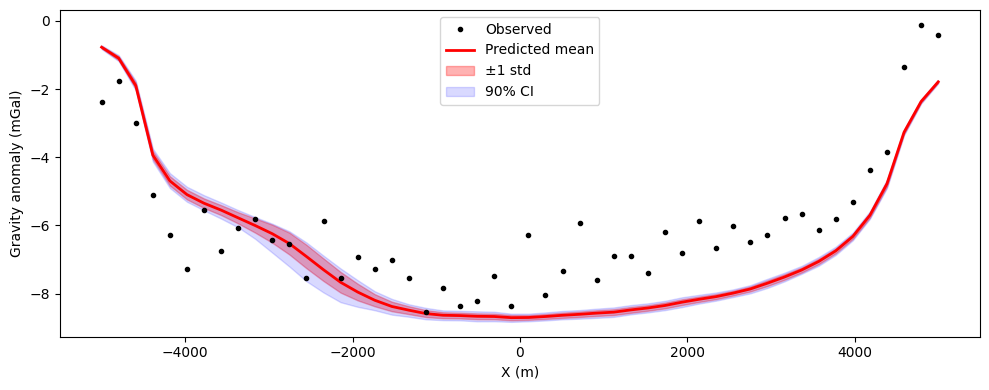

Mean residual : 0.0236 mGal
RMSE          : 0.2356 mGal


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# PREDICTED GRAVITY ANOMALY — POSTERIOR MEAN & STD
# ══════════════════════════════════════════════════════════════════════════════
params3 = mcmc3.get_samples()

# Number of posterior samples
n_samples = params3["B_D1"].shape[0]   # e.g. 100 (or 400 if 4 chains × 100)

x_1d = jnp.array(X).reshape(-1)       # observation points, shape: (n_obs,)

# --- Vectorized prediction over all samples at once ---
# params1["B_D1"]    shape: (n_samples, n_prisms)
# params1["density1"] shape: (n_samples, n_prisms)

def predict_single_sample(B_D1_s, B_D2_s, density1_s, density2_s):
    """Forward model for ONE posterior sample → shape: (n_obs,)"""
    return Bayes_Inf2(x_1d, B_D1_s, B_D2_s, density1_s, density2_s)

# vmap over all posterior samples in one shot — no Python loop
predict_all = jax.vmap(predict_single_sample)

g_pred_all = predict_all(
    jnp.array(params3["B_D1"]),       # (n_samples, n_prisms)
    jnp.array(params3["B_D2"]),       # (n_samples, n_prisms)
    jnp.array(params3["density1"]),   # (n_samples, n_prisms)
    jnp.array(params3["density2"]),   # (n_samples, n_prisms)
)
# g_pred_all shape: (n_samples, n_obs)

# --- Summary statistics ---
g_pred_mean3 = np.array(g_pred_all.mean(axis=0))   # shape: (n_obs,)
g_pred_std3  = np.array(g_pred_all.std(axis=0))    # shape: (n_obs,)
g_pred_p53   = np.array(jnp.percentile(g_pred_all, 5,  axis=0))   # lower 90% CI
g_pred_p953  = np.array(jnp.percentile(g_pred_all, 95, axis=0))   # upper 90% CI

# --- Quick plot ---
import matplotlib.pyplot as plt

x_plot = np.array(x_1d)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(x_plot, Y3,           'k.',  label="Observed",       zorder=5)
ax.plot(x_plot, g_pred_mean3,  'r-',  label="Predicted mean", lw=2)
ax.fill_between(x_plot,
                g_pred_mean3 - g_pred_std3,
                g_pred_mean3 + g_pred_std3,
                alpha=0.3, color='red', label="±1 std")
ax.fill_between(x_plot, g_pred_p53, g_pred_p953,
                alpha=0.15, color='blue', label="90% CI")
ax.set_xlabel("X (m)")
ax.set_ylabel("Gravity anomaly (mGal)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Mean residual : {np.mean(Y1 - g_pred_mean1):.4f} mGal")
print(f"RMSE          : {np.sqrt(np.mean((Y1 - g_pred_mean1)**2)):.4f} mGal")

# Compare Plot

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# ─────────────────────────────────────────────────────────────────────────────
# TRUE MODEL PARAMETERS (from your forward model)
# bd1, bd2   : true bottom depths of Layer 1 and Layer 2   shape (n,)
# den1, den2 : true density contrasts                      shape (n,) → scalar
# xs         : prism edge x-coordinates                    shape (n+1,)
# co         : prism centre x-coordinates                  shape (n,)
# n          : 30 prisms
# ─────────────────────────────────────────────────────────────────────────────
true_rho1 = den1_L   # -150  kg/m³  (uniform across prisms)
true_rho2 = den2_L   # -250  kg/m³

prism_idx = np.arange(1, n + 1)   # 1 … 30

# ─────────────────────────────────────────────────────────────────────────────
# COLOUR PALETTE  (consistent across every figure)
# ─────────────────────────────────────────────────────────────────────────────
C_NARROW   = "steelblue"
C_SPARSE   = "darkorange"
C_TRUE     = "crimson"
ALPHA_BAND = 0.20

# ─────────────────────────────────────────────────────────────────────────────

# Define X_test with 100 points for this plotting cell
X_test = jnp.linspace(X.min(), X.max(), 50)
X_test_np = np.array(X).flatten()
X_plot    = np.array(X).flatten()
y1_plot    = np.array(Y1).flatten()
y3_plot = np.array(Y3).flatten()

cmap_unc = plt.get_cmap('hot_r', 1000)       # white=low uncertainty, red=high

# =============================================================================
# FIGURE 1 — Side-by-side subsurface cross-sections
# =============================================================================
def plot_cross_section(ax,Y6, INV_DEP_TOP, INV_DEN_TOP, INV_DEP_BOTTOM, INV_DEN_BOTTOM, title,
                       predicted_mean=None, predicted_std=None, Gravity_anomaly=None,fault_x=None, vmin=-570, vmax=-270):
    cmap = plt.get_cmap("gist_rainbow", 1000)
    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

    # ── Top row: Gravity anomaly ──────────────────────────────
    ax[0].scatter(X, Y6, alpha=0.5, c='green', marker='o',s=10,
               label="Observed Noisy Data", zorder=2)

    if Gravity_anomaly is not None:
        # Use X_test_np for Gravity_anomaly if it's meant to be plotted at these points
        # Assuming measure_func expects X values as input
        ax[0].plot(X_test_np, Gravity_anomaly, c='red', linewidth=2,label='Noisefree Signal', zorder=1)
    # Only plot the mean and std if predicted_mean is provided
    if predicted_mean is not None:
        ax[0].plot(X_test, predicted_mean, '--', c='red', linewidth=2,
                    label='Predicted Mean', zorder=1)

        # Only process std if it's provided along with the mean
        if predicted_std is not None:
            if np.all(predicted_std==0):
               pass
            else:
              ax[0].fill_between(X_test_np,
                                predicted_mean - 2*predicted_std,
                                predicted_mean + 2*predicted_std,
                                color='r', alpha=0.2, label="Mean +- 2Std Dev Bound")

    ax[0].set_xlim(-5000, 5000)
    ax[0].set_ylabel("Gravity Anomaly(mGal)", weight="bold")
    ax[0].set_title(title, weight="bold")
    ax[0].legend(fontsize=8)

    # ── Bottom row: Cross-section model ──────────────────────
    for i in range(n):
        xl = xs[i]
        xr = xs[i + 1]

        # Layer 1
        z_top1 = 0.0
        z_bot1 = INV_DEP_TOP[i]
        col1   = cmap(norm(INV_DEN_TOP[i]))
        ax[1].fill([xl, xr, xr, xl],
                   [z_top1, z_top1, z_bot1, z_bot1], color=col1)
        ax[1].plot([xl, xr, xr, xl, xl],
                   [z_top1, z_top1, z_bot1, z_bot1, z_top1],
                   color="grey", lw=0.3)

        # Layer 2
        z_top2 = INV_DEP_TOP[i]
        z_bot2 = INV_DEP_BOTTOM[i]
        col2   = cmap(norm(INV_DEN_BOTTOM[i]))
        ax[1].fill([xl, xr, xr, xl],
                   [z_top2, z_top2, z_bot2, z_bot2], color=col2)
        ax[1].plot([xl, xr, xr, xl, xl],
                   [z_top2, z_top2, z_bot2, z_bot2, z_top2],
                   color="grey", lw=0.3)

    ax[1].plot(-1500 + fault_depths / np.tan(theta_fault),
         fault_depths, 'r--', linewidth=2, label="True Fault (-1500 m)")

    # Inverted fault line (blue dashed)
    ax[1].plot(fault_x + fault_depths / np.tan(theta_fault),
            fault_depths, 'b--', linewidth=2,
            label=f"Inv. Fault ({fault_x:.0f} m)")

    ax[1].set_ylim(1000, 0)
    ax[1].set_xlim(-4500, 4500)
    ax[1].set_xlabel("Profile (m)", weight="bold")
    ax[1].set_ylabel("Depth (m)", weight="bold")
    ax[1].legend(fontsize=8)
    plt.setp(ax[0].get_xticklabels(), visible= False)
    plt.setp(ax[0].get_yticklabels(), visible= True,weight='bold')
    plt.setp(ax[1].get_xticklabels(), visible= True,weight='bold')
    plt.setp(ax[1].get_yticklabels(), visible= True,weight='bold')


vmin, vmax = -570, -270
cmap = plt.get_cmap("gist_rainbow", 1000)
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

fig1, axs1 = plt.subplots(2, 2, figsize=(18, 6), dpi=300)
fig1.suptitle("INVERTED MODELS (Large noise vs Less noise)",
              fontsize=13, weight="bold")

# Corrected calls to plot_cross_section
# The first plot is the forward model, which needs the ground_truth corresponding to X_test_np


plot_cross_section(axs1[:, 0], Y1, top_inverted_depths1_1, top_density1, bottom_inverted_depths1_1, bottom_density1, "Inverted Model (For LESS NOISE)",
                   predicted_mean=g_pred_mean1, predicted_std=g_pred_std1,fault_x=fault_x_mean1)

# Sparse Prior Call
plot_cross_section(axs1[:, 1],Y3, top_inverted_depths1_3, top_density3, bottom_inverted_depths1_3, bottom_density3, "Inverted Model (For Large Noise)",
                   predicted_mean=g_pred_mean3, predicted_std=g_pred_std3,fault_x=fault_x_mean3)

# ... (rest of your colorbar code remains exactly the same)

# ── Reserve space on the right for the colorbar ───────────────────────────
plt.subplots_adjust(right=0.88)   # shrink subplots to 88% of figure width

# ── Add a dedicated axes for the colorbar [left, bottom, width, height] ──
cbar_ax = fig1.add_axes([0.90, 0.10, 0.015, 0.80])   # tall, narrow strip on the right

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig1.colorbar(sm, cax=cbar_ax, orientation="vertical",
                     ticks=np.linspace(vmin, vmax, 5))
cbar.set_label("Density Contrast (kg/m³)")

plt.show()

# =============================================================================
# FIGURE 2 — Per-prism depth comparison with min–max uncertainty band
# =============================================================================
fig2, axs2 = plt.subplots(2, 1, figsize=(16, 10), dpi=300, sharex=True)
fig2.suptitle("Inverted Depths — Mean ± Full Range  (Large vs Less Noise)",
              fontsize=13, weight="bold")

depth_pairs = [
    (axs2[0],
     "Layer 1 Bottom Depth",
     top_inverted_depths1_1, top_inverted_depths1_1_min, top_inverted_depths1_1_max,
     top_inverted_depths1_3, top_inverted_depths1_3_min, top_inverted_depths1_3_max,
     bd1),
    (axs2[1],
     "Layer 2 Bottom Depth",
     bottom_inverted_depths1_1, bottom_inverted_depths1_1_min, bottom_inverted_depths1_1_max,
     bottom_inverted_depths1_3, bottom_inverted_depths1_3_min, bottom_inverted_depths1_3_max,
     bd2),
]

for ax, label, n_mean, n_min, n_max, s_mean, s_min, s_max, true_d in depth_pairs:
    # Narrow prior band + mean
    ax.fill_between(prism_idx, n_min, n_max,
                    color=C_NARROW, alpha=ALPHA_BAND,
                    label="Less noise case range")
    ax.plot(prism_idx, n_mean, color=C_NARROW, lw=2,
            label="Less noise case mean")

    # Sparse prior band + mean
    ax.fill_between(prism_idx, s_min, s_max,
                    color=C_SPARSE, alpha=ALPHA_BAND,
                    label="Large noise case range")
    ax.plot(prism_idx, s_mean, color=C_SPARSE, lw=2, ls="--",
            label="Large noise case mean")

    # True depth
    ax.plot(prism_idx, true_d, color=C_TRUE, lw=1.8, ls="-.",
            label="True depth")

    ax.set_ylabel("Depth (m)", weight="bold")
    ax.set_title(label, weight="bold")
    ax.invert_yaxis()
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

axs2[1].set_xlabel("Prism Index", weight="bold")
axs2[1].set_xticks(prism_idx)
plt.tight_layout()
#plt.savefig("fig2_depth_comparison.png", dpi=150, bbox_inches="tight")
plt.setp(axs2[1].get_xticklabels(), visible= True,weight='bold')

plt.setp(axs2[1].get_yticklabels(), visible= True,weight='bold')
plt.setp(axs2[0].get_yticklabels(), visible= True,weight='bold')
plt.show()


# =============================================================================
# FIGURE 3 — Depth error & uncertainty width per prism (bar charts)
# =============================================================================
bar_w  = 0.38
offset = bar_w / 2 + 0.04

fig3, axs3 = plt.subplots(1, 2, figsize=(9, 3), dpi=300, sharex=True)
fig3.suptitle("Depth Mismatch(Inverted − True) — Large vs Less Noise Case",
              fontsize=11, weight="bold")

depth_specs = [
    ("Layer1 Depth Error",
     top_inverted_depths1_1 - bd1,
     top_inverted_depths1_3 - bd1,
     axs3[0]),
    ("Layer2 Depth Error",
     bottom_inverted_depths1_1 - bd2,
     bottom_inverted_depths1_3 - bd2,
     axs3[1]),

]

for title, n_vals, s_vals, ax in depth_specs:
    ax.bar(prism_idx - offset, n_vals, width=bar_w,
           color=C_NARROW, alpha=0.85, label="Less noise case")
    ax.bar(prism_idx + offset, s_vals, width=bar_w,
           color=C_SPARSE,  alpha=0.85, label="Large noise case")
    ax.axhline(0, color="black", lw=0.9)
    ax.set_title(title, weight="bold")
    ax.set_ylabel("Depth Error (m)", weight="bold")
    ax.grid(True, axis="y", alpha=0.3)
    # Show only every 10th tick from existing data
    ticks = ax.get_xticks()
    #ax.set_xticks(ticks[::10])
    ax.legend(fontsize=8)

for ax in axs3:
    ax.set_xlabel("Prism Index", weight="bold")
    ax.set_xticks(ticks[::1])

plt.tight_layout()
#plt.savefig("fig3_error_and_width.png", dpi=150, bbox_inches="tight")
plt.setp(axs3[1].get_xticklabels(), visible= True,weight='bold')
plt.setp(axs3[1].get_yticklabels(), visible= True,weight='bold')
plt.setp(axs3[0].get_yticklabels(), visible= True,weight='bold')
plt.setp(axs3[0].get_xticklabels(), visible= True,weight='bold')

plt.show()

# =============================================================================
# FIGURE 4 — Density uncertainity test
# =============================================================================

def plot_density_comparison(ax, INV_DEP_TOP, TOP_DEN_STD,BOTTOM_DEN_STD, INV_DEP_BOTTOM, INV_DEN_BOTTOM, title):
    cmap = plt.get_cmap("hot_r", 1000)
    norm = mpl.colors.Normalize(vmin=-0.5, vmax=1)
    min_std1=np.min(TOP_DEN_STD)
    max_std1=np.max(TOP_DEN_STD)
    A=(TOP_DEN_STD - min_std1) / (max_std1 - min_std1)
    min_std2=np.min(BOTTOM_DEN_STD)
    max_std2=np.max(BOTTOM_DEN_STD)
    B=(BOTTOM_DEN_STD - min_std2) / (max_std2 - min_std2)
    for i in range(n):
        xl = xs[i]
        xr = xs[i + 1]
        # Layer 1
        z_top1 = 0.0
        z_bot1 = INV_DEP_TOP[i]
        col1   = cmap(norm(A[i]))
        ax.fill([xl, xr, xr, xl],
                   [z_top1, z_top1, z_bot1, z_bot1], color=col1)
        ax.plot([xl, xr, xr, xl, xl],
                   [z_top1, z_top1, z_bot1, z_bot1, z_top1],
                   color="grey", lw=0.3)
        # Layer 2
        z_top2 = INV_DEP_TOP[i]
        z_bot2 = INV_DEP_BOTTOM[i]
        col2   = cmap(norm(B[i]))
        ax.fill([xl, xr, xr, xl],
                   [z_top2, z_top2, z_bot2, z_bot2], color=col2)
        ax.plot([xl, xr, xr, xl, xl],
                   [z_top2, z_top2, z_bot2, z_bot2, z_top2],
                   color="grey", lw=0.3)

    ax.set_ylim(1000, 0)
    ax.set_xlim(-4500, 4500)
    ax.set_xlabel("Profile (m)", weight="bold")
    ax.set_ylabel("Depth (m)", weight="bold")
    ax.set_title(title, weight="bold")
    plt.setp(ax.get_xticklabels(), visible= True,weight='bold')
    plt.setp(ax.get_yticklabels(), visible= True,weight='bold')

vmin, vmax = -0.5, 1
cmap = plt.get_cmap("hot_r", 1000)
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
fig4, axs4 = plt.subplots(1, 2, figsize=(16, 4), dpi=300)
fig4.suptitle("Posterior Std of Density Contrast(kg/m³)", fontsize=13, weight="bold")

plot_density_comparison(axs4[0], top_inverted_depths1_1, top_density1_std,bottom_density1_std, bottom_inverted_depths1, bottom_density1, "(For Less NOISE)")

plot_density_comparison(axs4[1], top_inverted_depths1_3, top_density3_std, bottom_density3_std, bottom_inverted_depths1_3, bottom_density3, "(For Large Noise)")

# ... (rest of your colorbar code remains exactly the same)

# ── Reserve space on the right for the colorbar ───────────────────────────
plt.subplots_adjust(right=0.88)   # shrink subplots to 88% of figure width

# ── Add a dedicated axes for the colorbar [left, bottom, width, height] ──
cbar_ax = fig4.add_axes([0.90, 0.15, 0.015, 0.80])   # tall, narrow strip on the right

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig4.colorbar(sm, cax=cbar_ax, orientation="vertical",
                     ticks=np.linspace(vmin, vmax, 5))
cbar.set_label("Std of Density Contrast (kg/m³)")
plt.xticks(ticks[::1500])
plt.show()